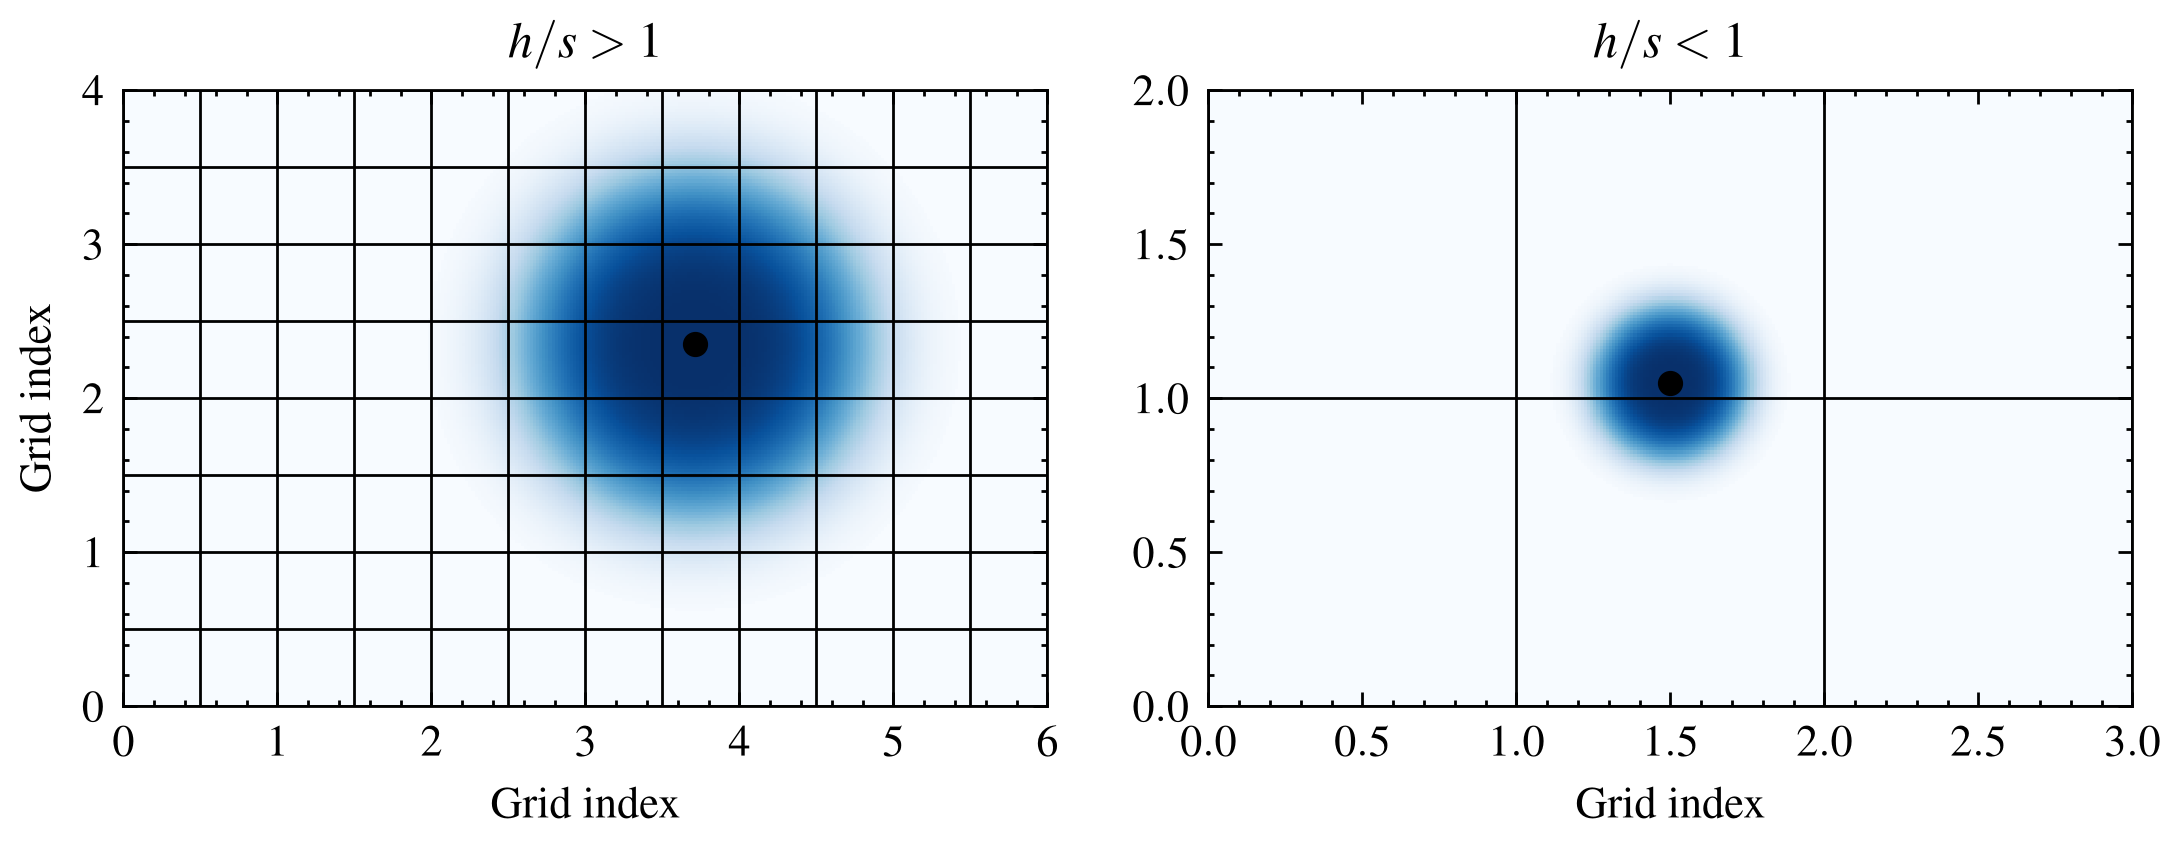

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from smudgy.utils import grid_lines

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('custom')

# grid
x = np.linspace(0, 6, 300)
y = np.linspace(0, 4, 200)
X, Y = np.meshgrid(x, y)

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=12,
    ny=8,
    include_edges=True
    )

# Gaussian kernel centered at (0, 0)
pos_center = (3.71, 2.35)
sigma = 1.0
q = (X-pos_center[0])**2 + (Y-pos_center[1])**2
W = np.exp(-q**2 / (2*sigma**2))
W = np.where(q <= 3*sigma, W, 0)

# plot
fig, ax = plt.subplots(1, 2, figsize=(7.0, 2))
im = ax[0].imshow(W, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", cmap="Blues")
ax[0].scatter(pos_center[0], pos_center[1], color="k", marker=".", s=50, label="center")

ax[0].hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[0].vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[0].set_xlabel("Grid index")
ax[0].set_ylabel("Grid index")
ax[0].set_xlim(x.min(), x.max())
ax[0].set_ylim(y.min(), y.max())
ax[0].set_title(r"$h/s > 1$", fontsize=9)


# grid
x = np.linspace(0, 3, 300)
y = np.linspace(0, 2, 200)
X, Y = np.meshgrid(x, y)

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=3,
    ny=2,
    include_edges=True
    )

# Gaussian kernel centered at (0, 0)
pos_center = (1.5, 1.05)
sigma = 0.05
q = (X-pos_center[0])**2 + (Y-pos_center[1])**2
W = np.exp(-q**2 / (2*sigma**2))
W = np.where(q <= 3*sigma, W, 0)

# plot
ax[1].scatter(pos_center[0], pos_center[1], color="k", marker=".", s=50, label="center")
im = ax[1].imshow(W, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", cmap="Blues")
ax[1].hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[1].vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[1].set_xlabel("Grid index")
ax[1].set_xlim(x.min(), x.max())
ax[1].set_ylim(y.min(), y.max())
ax[1].set_title(r"$h/s < 1$", fontsize=9)

plt.savefig("kernel_anti_alias.png", dpi=400, bbox_inches="tight", transparent=False)
plt.show()

n_q (radial shells) = 4
total samples       = 65
sum of weights       = 1.000000  (expect ~1.0)


/var/folders/g9/6lkt0k991jsbvwhk4pft359m0000gn/T/ipykernel_46024/2301543853.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", framealpha=0.9, fontsize=6)


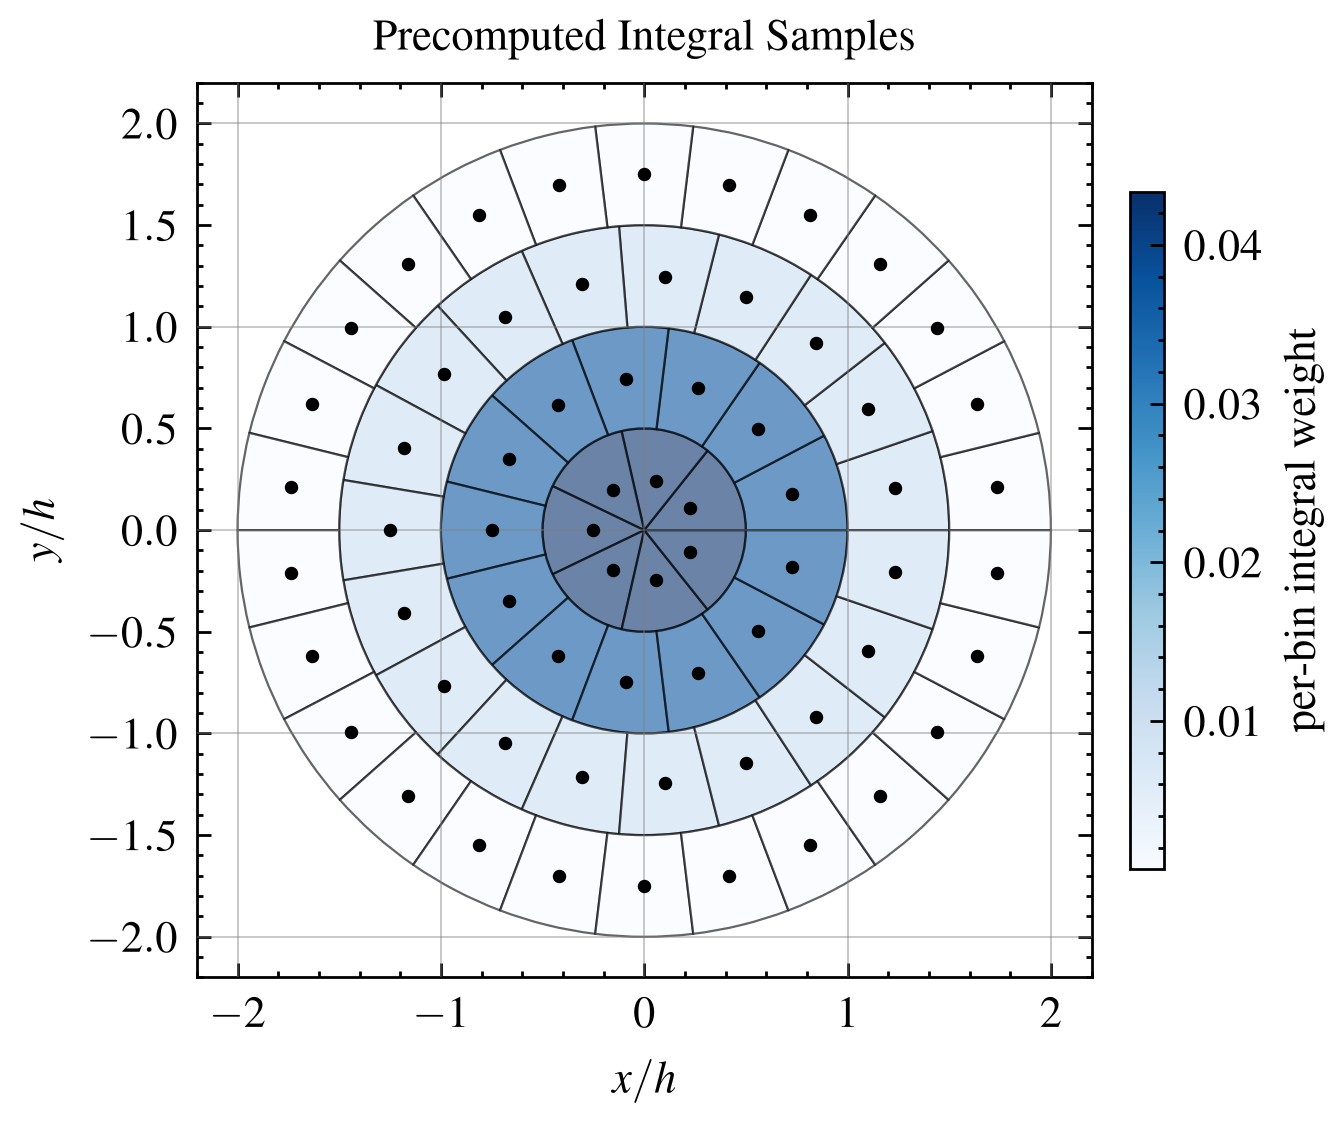

In [12]:
"""
Standalone script: build and visualize the 2D adaptive kernel sample grid
used by Smudgy's anti-aliasing fallback (eta < eta_crit branch).

Produces a scatter plot of the final sampled points in the x-y plane,
colored by their per-sample kernel-integral weight, with the underlying
grid cells and the kernel support circle overlaid for scale.

Dependencies: numpy, scipy, matplotlib (no Taichi, no package imports --
self-contained for documentation purposes).
"""

from __future__ import annotations

import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

pi = np.pi


# --------------------------------------------------------------------------
# Example kernel: cubic spline (M4), 2D-normalized.
# Swap this out for whichever kernel your documentation wants to illustrate
# -- only `kernel_shape` and `SIGMA_2D` / `SUPPORT` need to change.
# --------------------------------------------------------------------------

def kernel_shape(q: np.ndarray) -> np.ndarray:
    """Dimensionless cubic spline shape function f(q), q = r/h.
    W(r, h) = sigma / h^dim * f(q). Support: q in [0, 2]."""
    q = np.atleast_1d(q)
    f = np.zeros_like(q, dtype=np.float64)
    m1 = q < 1.0
    m2 = (q >= 1.0) & (q < 2.0)
    f[m1] = 1.0 - 1.5 * q[m1] ** 2 + 0.75 * q[m1] ** 3
    f[m2] = 0.25 * (2.0 - q[m2]) ** 3
    return f


SIGMA_2D = 10.0 / (7.0 * pi)   # cubic spline 2D normalization constant
SUPPORT = 2.0                  # k: kernel cutoff in units of h (q = r/h)


def evaluate_radial_integral(q0: float, q1: float) -> float:
    """Exact (numerically-integrated) radial integral of the kernel shape
    function over a shell: integral_{q0}^{q1} f(q) * q^{dim-1} dq, dim=2."""
    val, _ = quad(lambda q: kernel_shape(np.array([q]))[0] * q, q0, q1)
    return val


# --------------------------------------------------------------------------
# Sizing helpers -- functions of eta_crit only (Nyquist argument)
# --------------------------------------------------------------------------

def compute_n_q(eta_crit: float, nyquist_factor: float = 2.0) -> int:
    """Number of positive-radial shells. eta_crit is a DIAMETER ratio
    (eta = 2*k*h/s); Nyquist spacing applies to the radius."""
    eta_crit_radius = eta_crit / 2.0
    return max(1, int(np.ceil(nyquist_factor * eta_crit_radius)))


def n_points_circle_shell(u_outer: float, eta_crit_radius: float, nyquist_factor: float) -> int:
    """Number of uniformly-spaced angular samples on a shell of normalized
    outer radius u_outer, keeping point spacing <= s/nyquist_factor."""
    delta = 1.0 / nyquist_factor
    circumference = 2.0 * pi * eta_crit_radius * u_outer
    return max(1, int(np.ceil(circumference / delta)))


# --------------------------------------------------------------------------
# Shell layout builder (2D)
# --------------------------------------------------------------------------

def build_shell_layout_2d(support: float, eta_crit: float, nyquist_factor: float = 2.0):
    n_q = compute_n_q(eta_crit, nyquist_factor)
    dq = support / n_q
    shell_q0 = np.arange(n_q, dtype=np.float64) * dq
    shell_q1 = shell_q0 + dq

    eta_crit_radius = eta_crit / 2.0
    shell_id_chunks, theta0_chunks, theta1_chunks, n_points_per_shell = [], [], [], []
    for iq in range(n_q):
        u_outer = (iq + 1) / n_q
        n_pts = n_points_circle_shell(u_outer, eta_crit_radius, nyquist_factor)
        dtheta = 2.0 * pi / n_pts
        theta0 = np.arange(n_pts, dtype=np.float64) * dtheta
        theta1 = theta0 + dtheta

        shell_id_chunks.append(np.full(n_pts, iq, dtype=np.int32))
        theta0_chunks.append(theta0)
        theta1_chunks.append(theta1)
        n_points_per_shell.append(n_pts)

    shell_id = np.concatenate(shell_id_chunks)
    theta0 = np.concatenate(theta0_chunks)
    theta1 = np.concatenate(theta1_chunks)
    n_points_per_shell = np.array(n_points_per_shell, dtype=np.int32)

    return n_q, shell_q0, shell_q1, shell_id, theta0, theta1, n_points_per_shell


def build_kernel_sample_grid_2d(support: float, eta_crit: float, nyquist_factor: float = 2.0):
    """Build the full sample table: per-bin boundaries (q0, q1, theta0,
    theta1), bin-midpoint coordinates (in units of q = r/h), and per-bin
    kernel-integral weights, summing to ~1.0 over the table."""
    n_q, shell_q0, shell_q1, shell_id, theta0, theta1, n_points_per_shell = build_shell_layout_2d(
        support, eta_crit, nyquist_factor
    )

    # radial integral computed once per shell, not once per sample
    radial_integral = np.array(
        [evaluate_radial_integral(shell_q0[iq], shell_q1[iq]) for iq in range(n_q)]
    )

    q0 = shell_q0[shell_id]
    q1 = shell_q1[shell_id]
    q = 0.5 * (q0 + q1)
    thetaC = 0.5 * (theta0 + theta1)

    coords = np.stack([q * np.cos(thetaC), q * np.sin(thetaC)], axis=1)
    weights = SIGMA_2D * radial_integral[shell_id] * (2.0 * pi) / n_points_per_shell[shell_id]
    # note: the (2*pi) factor accounts for the full angular integral being
    # split evenly across n_points_per_shell directional samples, since
    # evaluate_radial_integral only integrates the radial part.

    return {
        "n_q": n_q,
        "count": coords.shape[0],
        "coords": coords,
        "q": q,
        "q0": q0,
        "q1": q1,
        "theta0": theta0,
        "theta1": theta1,
        "weights": weights,
    }


# --------------------------------------------------------------------------
# Plotting
# --------------------------------------------------------------------------

def plot_2d_sample_layout(table, s, support, eta_crit, title="Precomputed Integral Samples"):
    from matplotlib.patches import Wedge
    from matplotlib.collections import PatchCollection
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    q0, q1 = table["q0"], table["q1"]
    theta0, theta1 = table["theta0"], table["theta1"]
    weights = table["weights"]

    fig, ax = plt.subplots(figsize=(3.5, 4))

    norm = Normalize(vmin=weights.min(), vmax=weights.max())
    cmap = plt.get_cmap("Blues")

    wedges = [
        Wedge((0.0, 0.0), q1[i], np.degrees(theta0[i]), np.degrees(theta1[i]),
              width=q1[i] - q0[i])
        for i in range(len(weights))
    ]
    pc = PatchCollection(wedges, facecolor=cmap(norm(weights)),
                          edgecolor="k", linewidth=0.4, alpha=0.6)
    ax.add_collection(pc)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=ax, label="per-bin integral weight",
                 shrink=0.8, fraction=0.035, pad=0.04)

    ax.scatter(table["coords"][:, 0], table["coords"][:, 1],
               c="black", s=8, zorder=5)

    lim = support * 1.1
    for g in np.arange(-np.ceil(lim / s) * s, np.ceil(lim / s) * s + s, s):
        ax.axvline(g, color="gray", lw=0.3, alpha=0.5, zorder=3)
        ax.axhline(g, color="gray", lw=0.3, alpha=0.5, zorder=3)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel(r"$x / h$")
    ax.set_ylabel(r"$y / h$")
    ax.legend(loc="upper right", framealpha=0.9, fontsize=6)
    plt.tight_layout()
    return fig, ax


# --------------------------------------------------------------------------
# Entry point
# --------------------------------------------------------------------------

if __name__ == "__main__":
    eta_crit = 4.0     # default switching threshold (diameter convention)
    s = 1.0             # cell size, in units where h_max at the threshold
                        # gives support = eta_crit/2 (dimensionless demo)

    table = build_kernel_sample_grid_2d(SUPPORT, eta_crit, nyquist_factor=2.0)

    print(f"n_q (radial shells) = {table['n_q']}")
    print(f"total samples       = {table['count']}")
    print(f"sum of weights       = {table['weights'].sum():.6f}  (expect ~1.0)")

    fig, ax = plot_2d_sample_layout(table, s=s, support=SUPPORT, eta_crit=eta_crit)

    fig.savefig("kernel_sample_grid_2d.png", dpi=500, transparent=False)
    plt.show()